# Regression Detection — Evaluation

This notebook evaluates the detection pipeline using synthetic data.
No database connection is needed — we call `validate_regression` directly.

**Approach:**
1. Generate synthetic baseline and current windows for several scenarios
2. Label each scenario as a real regression or not (ground truth)
3. Run the detector and collect results
4. Calculate Precision, Recall, F1
5. Sweep the threshold to plot a Precision-Recall curve

In [35]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import lognorm
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '.')
from regression_detection.detector import validate_regression

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Synthetic Data Generation

Real mobile performance metrics are right-skewed (most frames are fast, a few are slow).
We use a **log-normal distribution** to simulate this, which is a common choice for latency data.

In [36]:
def generate_window(base_ms: float, n: int, spike_prob: float = 0.04,
                    spike_multiplier: float = 2.5, seed: int = None):
    """
    Realistic frame time data (ms).
    Most frames are tight around base_ms; a small fraction are dropped frames
    (isolated spikes). During a regression base_ms is higher and/or spike_prob rises.
    """
    rng = np.random.default_rng(seed)
    frames = rng.normal(loc=base_ms, scale=1.2, size=n)
    frames = np.clip(frames, base_ms * 0.5, None)
    spike_mask = rng.random(n) < spike_prob
    spike_values = rng.uniform(base_ms * spike_multiplier,
                               base_ms * (spike_multiplier + 1.0),
                               size=spike_mask.sum())
    frames[spike_mask] = spike_values
    return frames


def p95(values):
    return float(np.percentile(values, 95))


BASELINE_MEAN = 16.67   # 60 Hz target
N_SAMPLES     = 300

baseline = generate_window(BASELINE_MEAN, N_SAMPLES, seed=0)
print(f"Baseline — mean: {baseline.mean():.2f} ms  |  "
      f"median: {np.median(baseline):.2f} ms  |  P95: {p95(baseline):.2f} ms")

Baseline — mean: 17.44 ms  |  median: 16.63 ms  |  P95: 18.86 ms


## 1b. Visualizing the Synthetic Data

Before running the detector, it is useful to see what the generated data actually looks like.
Each row below shows one scenario. The **left plot** is the time series — baseline window followed by the current window. The **right plot** compares the distributions of both windows and highlights where the P95 lines fall.

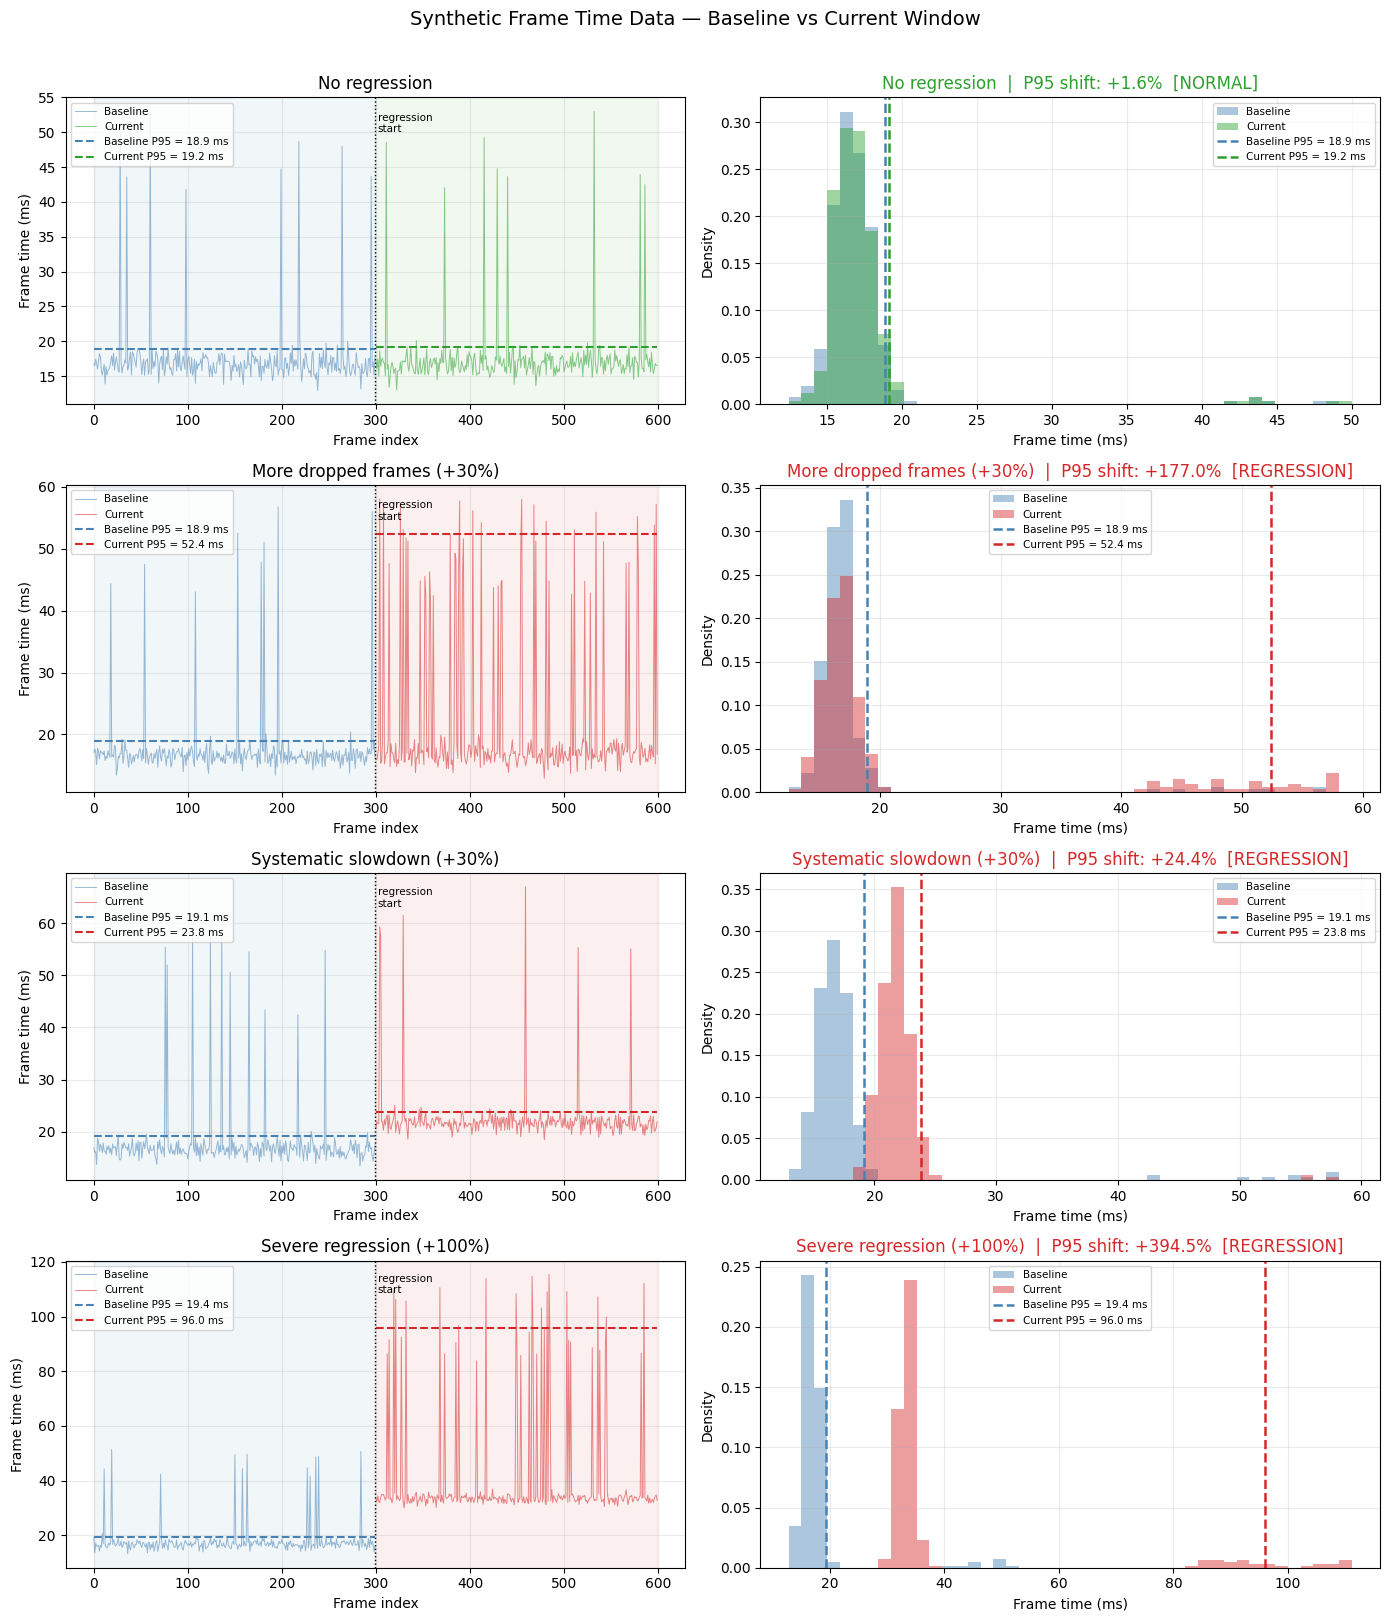

In [37]:
showcase = [
    # (name,                      base_ms,  spike_prob,  is_regression)
    ("No regression",             16.67,    0.04,         False),
    ("More dropped frames (+30%)", 16.67,   0.18,         True),   # same speed, more drops
    ("Systematic slowdown (+30%)", 21.67,   0.04,         True),   # base shift
    ("Severe regression (+100%)", 33.34,    0.10,         True),   # both effects
]

fig, axes = plt.subplots(len(showcase), 2, figsize=(14, 4 * len(showcase)))
fig.suptitle('Synthetic Frame Time Data — Baseline vs Current Window', fontsize=14, y=1.01)

for i, (name, curr_base, curr_spike, is_reg) in enumerate(showcase):
    base = generate_window(BASELINE_MEAN, N_SAMPLES, spike_prob=0.04, seed=i)
    curr = generate_window(curr_base,     N_SAMPLES, spike_prob=curr_spike, seed=i + 50)

    base_p95_val = p95(base)
    curr_p95_val = p95(curr)
    color_curr   = '#d62728' if is_reg else '#2ca02c'

    # ── Left: time series ─────────────────────────────────────────────────
    ax_ts = axes[i, 0]
    xs_base = np.arange(N_SAMPLES)
    xs_curr = np.arange(N_SAMPLES, 2 * N_SAMPLES)

    ax_ts.plot(xs_base, base, color='steelblue', alpha=0.55, linewidth=0.7, label='Baseline')
    ax_ts.plot(xs_curr, curr, color=color_curr,  alpha=0.55, linewidth=0.7, label='Current')

    ax_ts.hlines(base_p95_val, xs_base[0], xs_base[-1],
                 colors='steelblue', linestyles='--', linewidth=1.5,
                 label=f'Baseline P95 = {base_p95_val:.1f} ms')
    ax_ts.hlines(curr_p95_val, xs_curr[0], xs_curr[-1],
                 colors=color_curr, linestyles='--', linewidth=1.5,
                 label=f'Current P95 = {curr_p95_val:.1f} ms')

    ax_ts.axvspan(xs_base[0], xs_base[-1], alpha=0.07, color='steelblue')
    ax_ts.axvspan(xs_curr[0], xs_curr[-1], alpha=0.07, color=color_curr)
    ax_ts.axvline(x=N_SAMPLES - 0.5, color='black', linestyle=':', linewidth=1)
    ax_ts.text(N_SAMPLES + 2, ax_ts.get_ylim()[1] * 0.96,
               'regression\nstart', fontsize=7.5, va='top', color='black')

    ax_ts.set_title(name)
    ax_ts.set_xlabel('Frame index')
    ax_ts.set_ylabel('Frame time (ms)')
    ax_ts.legend(fontsize=7.5, loc='upper left')
    ax_ts.grid(True, alpha=0.25)

    # ── Right: distribution ───────────────────────────────────────────────
    ax_dist = axes[i, 1]
    all_vals = np.concatenate([base, curr])
    bins = np.linspace(all_vals.min() - 0.5, np.percentile(all_vals, 99) + 2, 45)

    ax_dist.hist(base, bins=bins, alpha=0.45, color='steelblue', label='Baseline', density=True)
    ax_dist.hist(curr, bins=bins, alpha=0.45, color=color_curr,  label='Current',  density=True)

    ax_dist.axvline(base_p95_val, color='steelblue', linestyle='--', linewidth=1.8,
                    label=f'Baseline P95 = {base_p95_val:.1f} ms')
    ax_dist.axvline(curr_p95_val, color=color_curr,  linestyle='--', linewidth=1.8,
                    label=f'Current P95 = {curr_p95_val:.1f} ms')

    rel_delta = (curr_p95_val - base_p95_val) / base_p95_val * 100
    status = 'REGRESSION' if is_reg else 'NORMAL'
    ax_dist.set_title(f'{name}  |  P95 shift: {rel_delta:+.1f}%  [{status}]',
                      color=color_curr)
    ax_dist.set_xlabel('Frame time (ms)')
    ax_dist.set_ylabel('Density')
    ax_dist.legend(fontsize=7.5)
    ax_dist.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## 2. Define Test Scenarios

Each scenario has:
- `label` — ground truth (True = real regression, False = no regression)
- `magnitude` — how much the mean frame time increased in the current window

We use several magnitudes to test sensitivity at different degradation levels.

In [38]:
scenarios = [
    # (name,                         base_ms,  spike_prob,  is_regression)
    ("No change",                     16.67,    0.04,        False),
    ("Tiny spike increase",           16.67,    0.06,        False),
    ("Small slowdown (+10%)",         18.34,    0.04,        False),
    ("More dropped frames (+30%)",    16.67,    0.18,        True),
    ("Systematic slowdown (+20%)",    20.00,    0.04,        True),
    ("Systematic slowdown (+50%)",    25.00,    0.06,        True),
    ("Severe regression (+100%)",     33.34,    0.10,        True),
    ("Noise only",                    16.67,    0.04,        False),
    ("Moderate regression",           21.00,    0.08,        True),
    ("Extreme regression",            40.00,    0.15,        True),
]

records = []
for seed_offset in range(20):
    for name, curr_base, curr_spike, is_regression in scenarios:
        base = generate_window(BASELINE_MEAN, N_SAMPLES, spike_prob=0.04, seed=seed_offset)
        curr = generate_window(curr_base,     N_SAMPLES, spike_prob=curr_spike,
                               seed=seed_offset + 100)
        records.append({
            'scenario':     name,
            'curr_base':    curr_base,
            'ground_truth': is_regression,
            'baseline':     base,
            'current':      curr,
            'baseline_p95': p95(base),
            'current_p95':  p95(curr),
        })

print(f"Total test cases: {len(records)}")

Total test cases: 200


## 3. Run the Detector

We call `validate_regression` from the actual production code — no modifications needed.

In [39]:
DEFAULT_THRESHOLD = 0.15  # matches config.py DEFAULT_P95_THRESHOLD

results = []
for r in records:
    detected, p_value = validate_regression(
        baseline_values=list(r['baseline']),
        current_values=list(r['current']),
        baseline_p95=r['baseline_p95'],
        current_p95=r['current_p95'],
        p95_threshold=DEFAULT_THRESHOLD,
    )
    results.append({
        'scenario':     r['scenario'],
        'curr_base':    r['curr_base'],
        'ground_truth': r['ground_truth'],
        'detected':     detected,
        'p_value':      p_value,
        'baseline_p95': r['baseline_p95'],
        'current_p95':  r['current_p95'],
    })

df = pd.DataFrame(results)
df.head(10)

,scenario,curr_base,ground_truth,detected,p_value,baseline_p95,current_p95
0,No change,16.67,False,False,NaN,18.864708,18.881011
1,Tiny spike increase,16.67,False,False,NaN,18.864708,19.373407
2,Small slowdown (+10%),18.34,False,False,NaN,18.864708,20.551011
3,More dropped frames (+30%),16.67,True,True,1.042394e-04,18.864708,52.841526
4,Systematic slowdown (+20%),20.00,True,True,4.135395e-82,18.864708,22.211011
5,Systematic slowdown (+50%),25.00,True,True,3.010100e-90,18.864708,27.703407
6,Severe regression (+100%),33.34,True,True,1.119916e-90,18.864708,95.991957
7,Noise only,16.67,False,False,NaN,18.864708,18.881011
8,Moderate regression,21.00,True,True,6.451321e-89,18.864708,58.608347
9,Extreme regression,40.00,True,True,2.030933e-91,18.864708,123.839254


## 4. Confusion Matrix

Threshold : 15%
TP=112  TN=73  FP=7  FN=8
Precision : 0.941
Recall    : 0.933
F1-score  : 0.937
FP rate   : 0.087


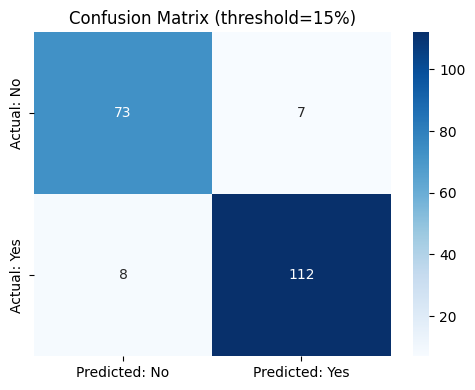

In [40]:
TP = ((df['ground_truth'] == True)  & (df['detected'] == True)).sum()
TN = ((df['ground_truth'] == False) & (df['detected'] == False)).sum()
FP = ((df['ground_truth'] == False) & (df['detected'] == True)).sum()
FN = ((df['ground_truth'] == True)  & (df['detected'] == False)).sum()

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
fpr       = FP / (FP + TN) if (FP + TN) > 0 else 0

print(f"Threshold : {DEFAULT_THRESHOLD:.0%}")
print(f"TP={TP}  TN={TN}  FP={FP}  FN={FN}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"F1-score  : {f1:.3f}")
print(f"FP rate   : {fpr:.3f}")

# Plot confusion matrix
cm = np.array([[TN, FP], [FN, TP]])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'], ax=ax)
ax.set_title(f'Confusion Matrix (threshold={DEFAULT_THRESHOLD:.0%})')
plt.tight_layout()
plt.show()

## 5. Results by Scenario

In [41]:
summary = (
    df.groupby(['scenario', 'curr_base', 'ground_truth'])
    .agg(
        total=('detected', 'count'),
        detected_count=('detected', 'sum'),
    )
    .reset_index()
)
summary['detection_rate'] = summary['detected_count'] / summary['total']
summary = summary.sort_values('curr_base')
summary

,scenario,curr_base,ground_truth,total,detected_count,detection_rate
2,More dropped frames (+30%),16.67,True,20,19,0.95
3,No change,16.67,False,20,1,0.05
4,Noise only,16.67,False,20,1,0.05
9,Tiny spike increase,16.67,False,20,2,0.10
6,Small slowdown (+10%),18.34,False,20,3,0.15
7,Systematic slowdown (+20%),20.00,True,20,13,0.65
1,Moderate regression,21.00,True,20,20,1.00
8,Systematic slowdown (+50%),25.00,True,20,20,1.00
5,Severe regression (+100%),33.34,True,20,20,1.00
0,Extreme regression,40.00,True,20,20,1.00


## 6. Precision-Recall Curve (Threshold Sweep)

We sweep the P95 threshold from 5% to 50% to see how Precision and Recall change.
This helps to justify the default 15% threshold used in the system.

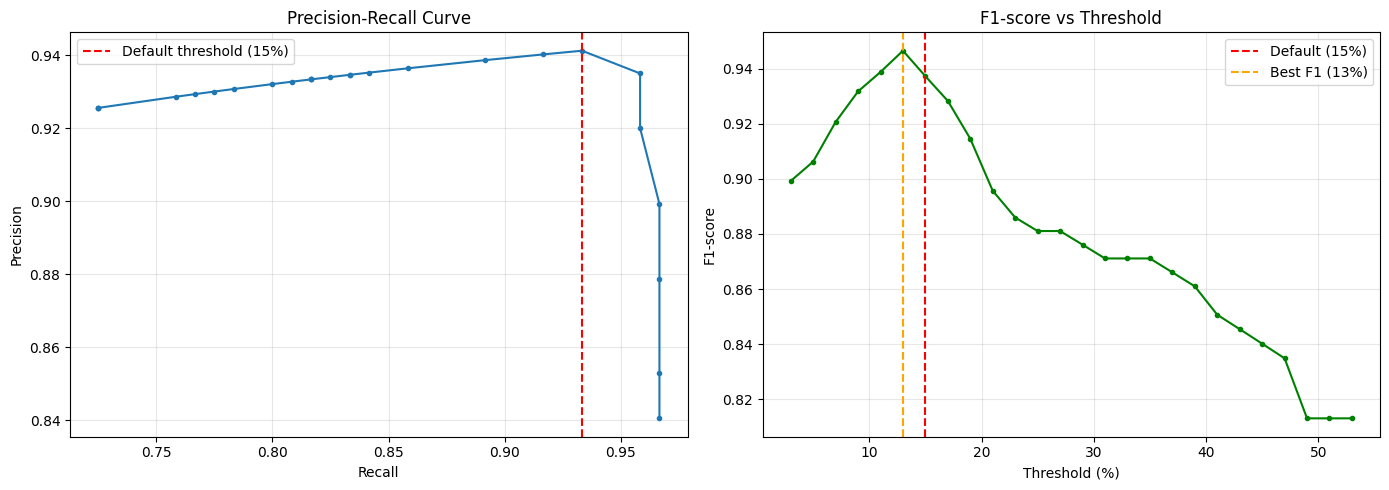

Best F1 threshold: 13%  (Precision=0.935, Recall=0.958, F1=0.947)


In [42]:
thresholds = np.arange(0.03, 0.55, 0.02)
pr_rows = []

for thr in thresholds:
    tp = fp = fn = tn = 0
    for r in records:
        detected, _ = validate_regression(
            baseline_values=list(r['baseline']),
            current_values=list(r['current']),
            baseline_p95=r['baseline_p95'],
            current_p95=r['current_p95'],
            p95_threshold=thr,
        )
        gt = r['ground_truth']
        if gt and detected:     tp += 1
        elif gt and not detected: fn += 1
        elif not gt and detected: fp += 1
        else:                   tn += 1

    p = tp / (tp + fp) if (tp + fp) > 0 else 1.0
    r_ = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f = 2 * p * r_ / (p + r_) if (p + r_) > 0 else 0.0
    pr_rows.append({'threshold': thr, 'precision': p, 'recall': r_, 'f1': f})

pr_df = pd.DataFrame(pr_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall curve
axes[0].plot(pr_df['recall'], pr_df['precision'], marker='o', markersize=3)
axes[0].axvline(x=pr_df.loc[pr_df['threshold'].sub(DEFAULT_THRESHOLD).abs().idxmin(), 'recall'],
                color='red', linestyle='--', label=f'Default threshold ({DEFAULT_THRESHOLD:.0%})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1 vs threshold
axes[1].plot(pr_df['threshold'] * 100, pr_df['f1'], marker='o', markersize=3, color='green')
best_thr = pr_df.loc[pr_df['f1'].idxmax(), 'threshold']
axes[1].axvline(x=DEFAULT_THRESHOLD * 100, color='red', linestyle='--',
                label=f'Default ({DEFAULT_THRESHOLD:.0%})')
axes[1].axvline(x=best_thr * 100, color='orange', linestyle='--',
                label=f'Best F1 ({best_thr:.0%})')
axes[1].set_xlabel('Threshold (%)')
axes[1].set_ylabel('F1-score')
axes[1].set_title('F1-score vs Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best = pr_df.loc[pr_df['f1'].idxmax()]
print(f"Best F1 threshold: {best['threshold']:.0%}  "
      f"(Precision={best['precision']:.3f}, Recall={best['recall']:.3f}, F1={best['f1']:.3f})")

## 7. Detection Latency

How quickly does the detector catch a regression that starts at time T?
We simulate a time series and check at each step whether the regression is detected.

,Scenario,Samples to detect
0,+15% (systematic),70
1,+30% (systematic),30
2,+50% (systematic),30
3,+100% (systematic),30
4,+30% (more drops),60
5,+100% (both),30


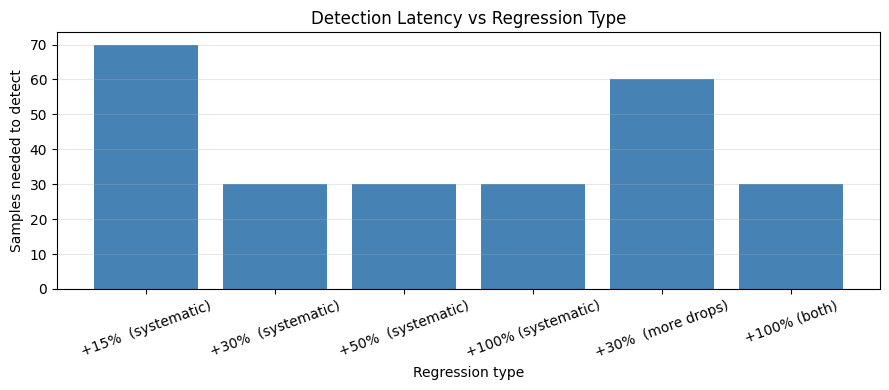

In [43]:
def simulate_latency(regression_base_ms, regression_spike_prob=0.04,
                     n_baseline=300, step_size=10, max_steps=30,
                     threshold=DEFAULT_THRESHOLD):
    base = generate_window(BASELINE_MEAN, n_baseline, spike_prob=0.04, seed=1)
    base_p95 = p95(base)

    for step in range(1, max_steps + 1):
        n_current = step * step_size
        curr = generate_window(regression_base_ms, n_current,
                               spike_prob=regression_spike_prob, seed=step)
        curr_p95 = p95(curr)
        detected, _ = validate_regression(
            baseline_values=list(base),
            current_values=list(curr),
            baseline_p95=base_p95,
            current_p95=curr_p95,
            p95_threshold=threshold,
        )
        if detected:
            return n_current
    return None


magnitudes = [
    ("+15%  (systematic)", 19.17, 0.04),
    ("+30%  (systematic)", 21.67, 0.04),
    ("+50%  (systematic)", 25.00, 0.04),
    ("+100% (systematic)", 33.34, 0.04),
    ("+30%  (more drops)", 16.67, 0.18),
    ("+100% (both)",       33.34, 0.12),
]

latency_results = []
for label, base_ms, spike_p in magnitudes:
    lat = simulate_latency(base_ms, spike_p)
    latency_results.append({
        'Scenario': label,
        'Samples to detect': lat if lat else '>300',
    })

lat_df = pd.DataFrame(latency_results)
display(lat_df)

numeric = lat_df[lat_df['Samples to detect'] != '>300'].copy()
numeric['Samples to detect'] = numeric['Samples to detect'].astype(int)
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(numeric['Scenario'], numeric['Samples to detect'], color='steelblue')
ax.set_xlabel('Regression type')
ax.set_ylabel('Samples needed to detect')
ax.set_title('Detection Latency vs Regression Type')
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Final Summary Table

In [44]:
summary_rows = []
for thr in [0.10, 0.15, 0.20, 0.25]:
    tp = fp = fn = tn = 0
    for r in records:
        detected, _ = validate_regression(
            baseline_values=list(r['baseline']),
            current_values=list(r['current']),
            baseline_p95=r['baseline_p95'],
            current_p95=r['current_p95'],
            p95_threshold=thr,
        )
        gt = r['ground_truth']
        if gt and detected:       tp += 1
        elif gt and not detected: fn += 1
        elif not gt and detected: fp += 1
        else:                     tn += 1

    p  = tp / (tp + fp) if (tp + fp) > 0 else 1.0
    rc = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * p * rc / (p + rc) if (p + rc) > 0 else 0.0
    fpr_ = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    summary_rows.append({
        'Threshold': f'{thr:.0%}',
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'Precision': round(p, 3),
        'Recall':    round(rc, 3),
        'F1':        round(f1, 3),
        'FP Rate':   round(fpr_, 3),
    })

pd.DataFrame(summary_rows)

,Threshold,TP,TN,FP,FN,Precision,Recall,F1,FP Rate
0,10%,115,67,13,5,0.898,0.958,0.927,0.163
1,15%,112,73,7,8,0.941,0.933,0.937,0.087
2,20%,105,73,7,15,0.938,0.875,0.905,0.087
3,25%,100,73,7,20,0.935,0.833,0.881,0.087


## 9. Rolling Detection — When Is the Alert Raised?

This chart shows a single continuous time series: a normal period followed by an injected regression. The detection algorithm runs on a sliding window after each new frame arrives. The vertical red line marks the exact moment the alert is raised.

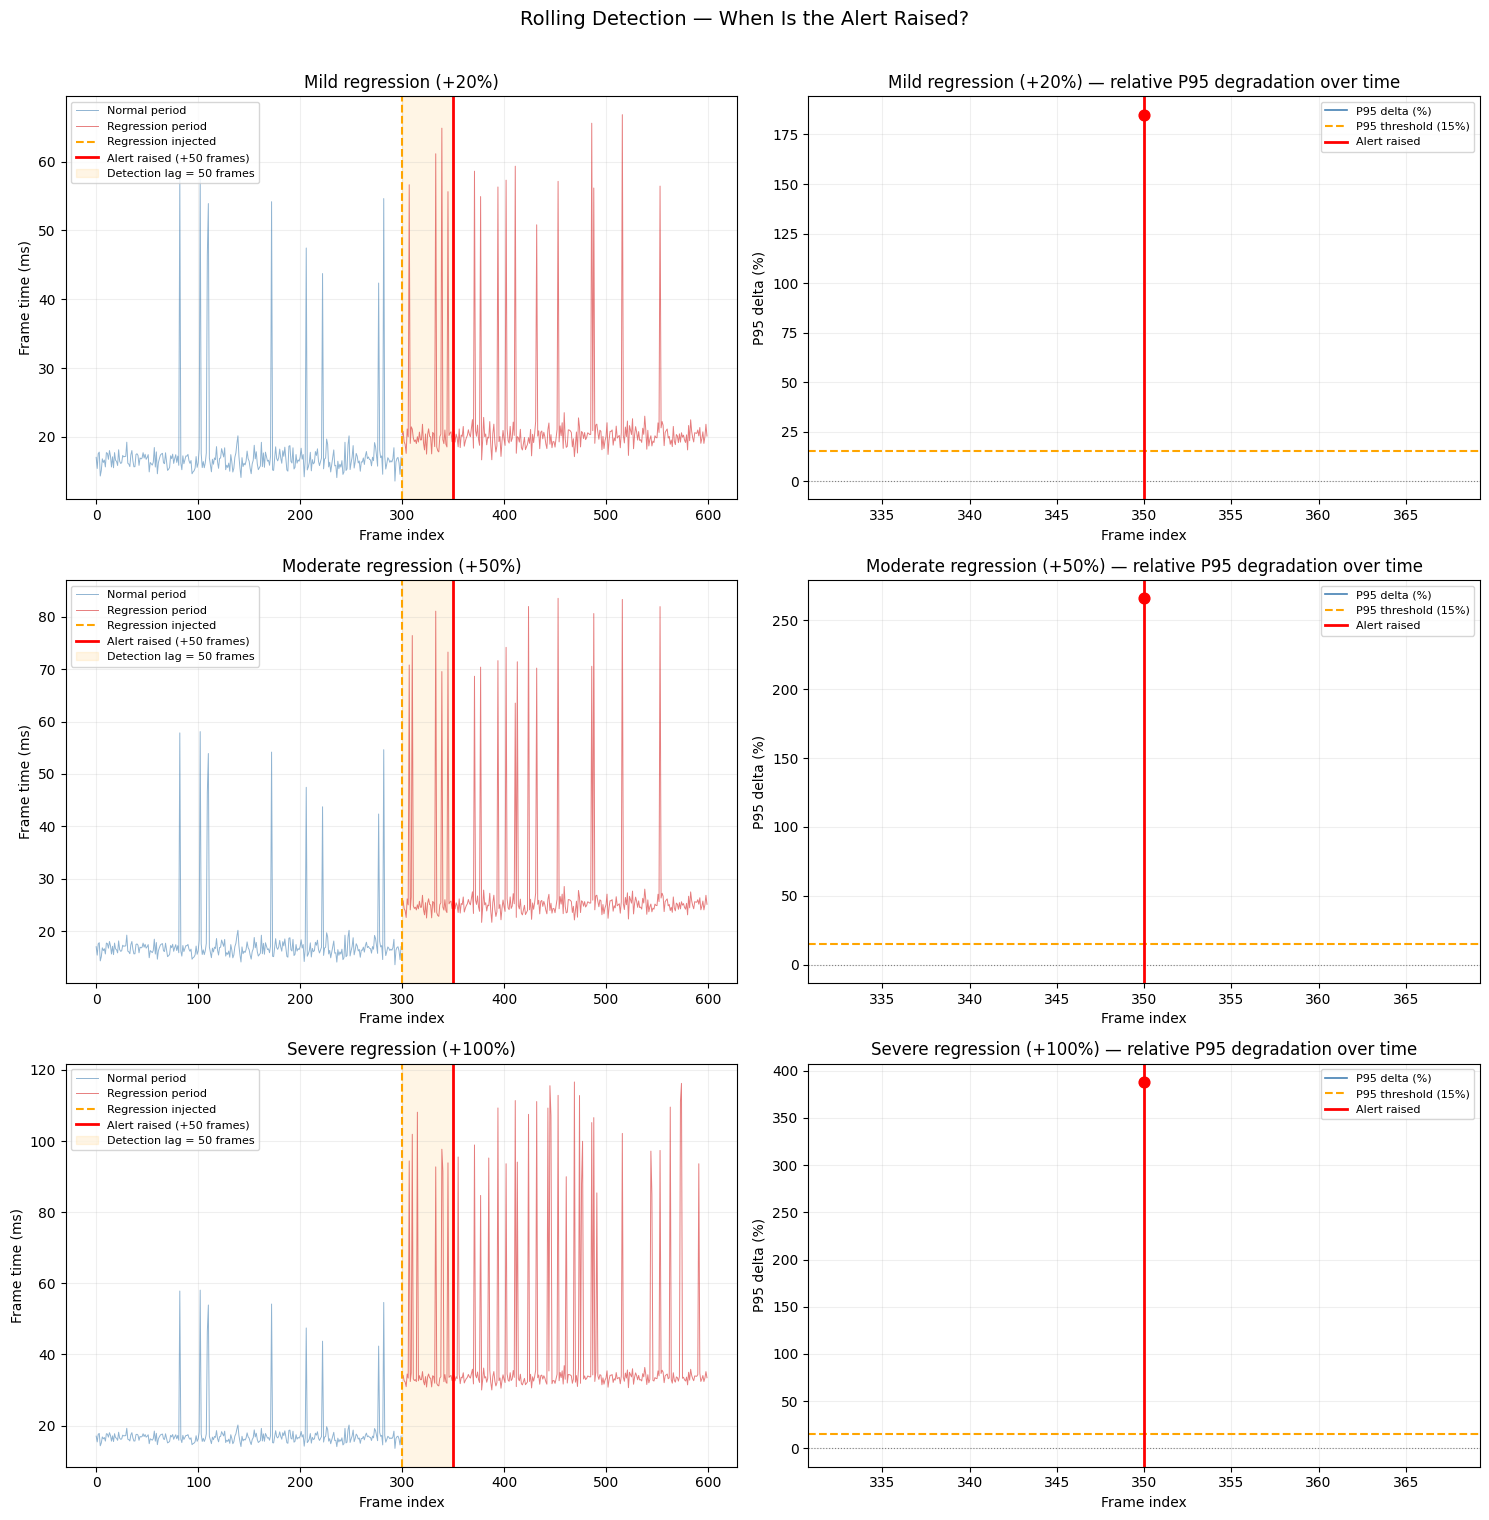

Scenario                         Latency (frames)
--------------------------------------------------
Mild regression (+20%)                         50
Moderate regression (+50%)                     50
Severe regression (+100%)                      50


In [45]:
def rolling_detection(
    n_baseline       = 300,    # frames before regression starts
    n_after          = 300,    # frames after regression starts
    regression_base  = 25.0,   # new target frame time after regression
    regression_spike = 0.10,   # new spike probability after regression
    baseline_window  = 200,    # how many frames are used as baseline reference
    current_window   = 50,     # how many frames are used as the current window
    step             = 5,      # check every N new frames
    threshold        = DEFAULT_THRESHOLD,
    seed             = 42,
):
    """
    Simulate real-time detection on a streaming time series.

    Returns:
        frames        : the full array of frame times
        alert_index   : index where the algorithm first raises an alert (or None)
        check_indices : list of indices where the detector was evaluated
        deltas        : relative P95 delta at each check
    """
    rng = np.random.default_rng(seed)

    # Build the full time series
    normal    = generate_window(BASELINE_MEAN, n_baseline,
                                spike_prob=0.04, seed=seed)
    regressed = generate_window(regression_base, n_after,
                                spike_prob=regression_spike, seed=seed + 1)
    frames = np.concatenate([normal, regressed])

    alert_index   = None
    check_indices = []
    deltas        = []

    # Slide forward — start checking once we have enough data
    start = n_baseline + current_window
    for i in range(start, len(frames), step):
        baseline_slice = frames[max(0, i - baseline_window - current_window)
                                : i - current_window]
        current_slice  = frames[i - current_window : i]

        if len(baseline_slice) < 30 or len(current_slice) < 30:
            continue

        bp95 = p95(baseline_slice)
        cp95 = p95(current_slice)
        delta = (cp95 - bp95) / bp95 if bp95 > 0 else 0

        check_indices.append(i)
        deltas.append(delta)

        detected, _ = validate_regression(
            baseline_values=list(baseline_slice),
            current_values=list(current_slice),
            baseline_p95=bp95,
            current_p95=cp95,
            p95_threshold=threshold,
        )
        if detected and alert_index is None:
            alert_index = i
            break   # stop at first confirmed alert

    return frames, alert_index, check_indices, deltas, n_baseline


# ── Run for three regression magnitudes ──────────────────────────────────────
scenarios_rolling = [
    ("Mild regression (+20%)",    20.0,  0.04),
    ("Moderate regression (+50%)", 25.0, 0.06),
    ("Severe regression (+100%)", 33.34, 0.12),
]

fig, axes = plt.subplots(len(scenarios_rolling), 2, figsize=(15, 5 * len(scenarios_rolling)))
fig.suptitle('Rolling Detection — When Is the Alert Raised?', fontsize=14, y=1.01)

for i, (name, reg_base, reg_spike) in enumerate(scenarios_rolling):
    frames, alert_idx, check_idx, deltas, regression_start = rolling_detection(
        regression_base=reg_base,
        regression_spike=reg_spike,
    )

    xs = np.arange(len(frames))

    # ── Left: time series with alert marker ───────────────────────────────
    ax = axes[i, 0]

    # Normal period
    ax.plot(xs[:regression_start], frames[:regression_start],
            color='steelblue', linewidth=0.7, alpha=0.6, label='Normal period')
    # Regression period
    ax.plot(xs[regression_start:], frames[regression_start:],
            color='#d62728', linewidth=0.7, alpha=0.6, label='Regression period')

    # Where regression started
    ax.axvline(regression_start, color='orange', linewidth=1.5,
               linestyle='--', label='Regression injected')

    # Where alert was raised
    if alert_idx is not None:
        latency = alert_idx - regression_start
        ax.axvline(alert_idx, color='red', linewidth=2.0,
                   linestyle='-', label=f'Alert raised (+{latency} frames)')
        ax.axvspan(regression_start, alert_idx, alpha=0.10, color='orange',
                   label=f'Detection lag = {latency} frames')
    else:
        ax.text(0.6, 0.92, 'Not detected', transform=ax.transAxes,
                color='red', fontsize=10, ha='center',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    ax.set_title(name)
    ax.set_xlabel('Frame index')
    ax.set_ylabel('Frame time (ms)')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.2)

    # ── Right: P95 delta over time ────────────────────────────────────────
    ax2 = axes[i, 1]

    delta_pct = [d * 100 for d in deltas]
    ax2.plot(check_idx, delta_pct, color='steelblue', linewidth=1.2, label='P95 delta (%)')
    ax2.axhline(DEFAULT_THRESHOLD * 100, color='orange', linestyle='--', linewidth=1.5,
                label=f'P95 threshold ({DEFAULT_THRESHOLD:.0%})')
    ax2.axhline(0, color='gray', linestyle=':', linewidth=0.8)

    if alert_idx is not None:
        ax2.axvline(alert_idx, color='red', linewidth=2.0,
                    linestyle='-', label='Alert raised')
        ax2.scatter([alert_idx], [delta_pct[check_idx.index(alert_idx)]],
                    color='red', zorder=5, s=60)

    ax2.set_title(f'{name} — relative P95 degradation over time')
    ax2.set_xlabel('Frame index')
    ax2.set_ylabel('P95 delta (%)')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Print summary
print(f"{'Scenario':<30} {'Latency (frames)':>18}")
print('-' * 50)
for name, reg_base, reg_spike in scenarios_rolling:
    frames, alert_idx, *_, reg_start = rolling_detection(
        regression_base=reg_base, regression_spike=reg_spike)
    lat = alert_idx - reg_start if alert_idx else 'Not detected'
    print(f"{name:<30} {str(lat):>18}")